In [1]:
## Load libraries
from src.gtfs_stops_ingestion import load_gtfs_stops
from src.otp_travel_time import get_time
import requests
import json
import zipfile
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from concurrent.futures import ThreadPoolExecutor, as_completed

## Input contract

This notebook assumes as input a **GeoDataFrame of points** with the following properties:

- Each row represents a **hexagon centroid**
- A unique and non-null `point_id` column exists
- The active geometry is of type **Point**
- The CRS matches the **project canonical CRS**

⚠️ **If any of these conditions are not met, the analysis is not valid.**

In [2]:
## Global parameters
PROJECT_CRS = "EPSG:4326"  # Project canonical CRS
METRIC_CRS = "EPSG:3763"   # CRS for planar projection
RADIO_WALK = 4000          # Geometric radius-based pre-filter for points
OTP_BASE_URL = "http://otp-serve:8080/otp/gtfs/v1"
MODE = "WALK"              # WALK, BICYCLE or TRANSIT
WALK_DATETIME = "2025-12-10T08:00:00Z"

In [3]:
points = gpd.read_file("/results/points_hex_500m_wgs84.geojson")
zip_path_mdp = "/data/mdp_gtfs.zip"

In [4]:
assert isinstance(points, gpd.GeoDataFrame), "Input is not a GeoDataFrame"
assert points.geom_type.unique().tolist() == ["Point"], "Geometry is not Point"
assert points.crs == PROJECT_CRS, "Incorrect CRS in points"
assert "point_id" in points.columns, "Missing point_id column"
assert points["point_id"].is_unique, "point_id is not unique"
assert points["point_id"].isna().sum() == 0, "point_id contains null values"

In [5]:
## Load and convert GTFS stops to geometry (canonical CRS)
stops_gdf = load_gtfs_stops(
    zip_path=zip_path_mdp,
    txt_filename="stops.txt",
    PROJECT_CRS=PROJECT_CRS
)

# Reproject points and stations to a projected CRS
points_m = points.to_crs(METRIC_CRS)
stops_m = stops_gdf.to_crs(METRIC_CRS)

In [6]:
## Pre-calculation of the number of WALK combinations
assert points_m.crs == METRIC_CRS
assert stops_m.crs == METRIC_CRS

rows = []
total = 0
processed = 0

for _, p in points_m.iterrows():
    total += stops_m.distance(p.geometry).le(RADIO_WALK).sum()

print(f"Actual total number of WALK combinations: {total}")

Actual total number of WALK combinations: 6329


In [7]:
## Calculation of travel times (point–stop)
def compute_point_station(p, s):
    t = get_time(
        lat=p["lat"],
        lon=p["lon"],
        dest_lat=s["stop_lat"],
        dest_lon=s["stop_lon"],
        mode=MODE,
        base_url=OTP_BASE_URL,
        datetime_iso=WALK_DATETIME
    )

    if t is None:
        return {
            "point_id": p["point_id"],
            "station_id": s["stop_id"],
            "duration_min": None,
            "distance_m": None,
            "by_mode": None
        }

    return {
        "point_id": p["point_id"],
        "station_id": s["stop_id"],
        "duration_min": t["total"]["duration_min"],
        "distance_m": t["total"]["distance_m"],
        "by_mode": t["by_mode"]
    }

In [9]:
## Test functions
print(get_time(
    lat=41.16353,
    lon=-8.654582,
    dest_lat=41.16432,
    dest_lon=-8.617664,
    mode=MODE,
    base_url=OTP_BASE_URL,
    datetime_iso=WALK_DATETIME
))

{'total': {'distance_m': 3626.26, 'duration_min': 61.92}, 'by_mode': {'WALK': {'distance_m': 3626.26, 'duration_min': 61.92}}}


In [12]:
## Parallel execution of WALK travel time queries
max_workers = 12
processed = 0

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    for idx_p, p in points_m.iterrows():

        # filtro geométrico
        candidate_stops = stops_m[
            stops_m.geometry.distance(p.geometry) <= RADIO_WALK
        ]

        if candidate_stops.empty:
            continue

        futures = [
            executor.submit(compute_point_station, p, s)
            for _, s in candidate_stops.iterrows()
        ]

        for f in as_completed(futures):
            try:
                rows.append(f.result())
            except Exception:
                pass
            processed += 1
            if processed % 50 == 0 or processed == total:
                print(f"Processing {processed}/{total}", end="\r", flush=True)

In [21]:
## Post-processing of WALK travel times
df = pd.DataFrame(rows)

# Remove routes without a valid travel time (no route / error / timeout).
# From this point on, only combinations with computed WALK times are analyzed.
df = df.dropna(subset=["duration_min"])

# Stations reachable within ≤30 minutes walking
df_30 = df[df["duration_min"] <= 30]

# Count per point (≤30 minutes)
n30 = (
    df_30
    .groupby("point_id")
    .size()
    .reset_index(name="n_metro_30min_walk")
)

# Stations reachable within ≤15 minutes walking
df_15 = df[df["duration_min"] <= 15]

# Count per point (≤15 minutes)
n15 = (
    df_15
    .groupby("point_id")
    .size()
    .reset_index(name="n_metro_15min_walk")
)

In [29]:
## Integration of WALK results
points_plot = points.merge(
    n30,
    on="point_id",
    how="left"
)

points_plot = points_plot.merge(
    n15,
    on="point_id",
    how="left"
)

# Points are considered accessible if they have at least one station
# reachable within ≤30 minutes walking.
points_accessible = points_plot[
    points_plot["n_metro_30min_walk"] > 0
]

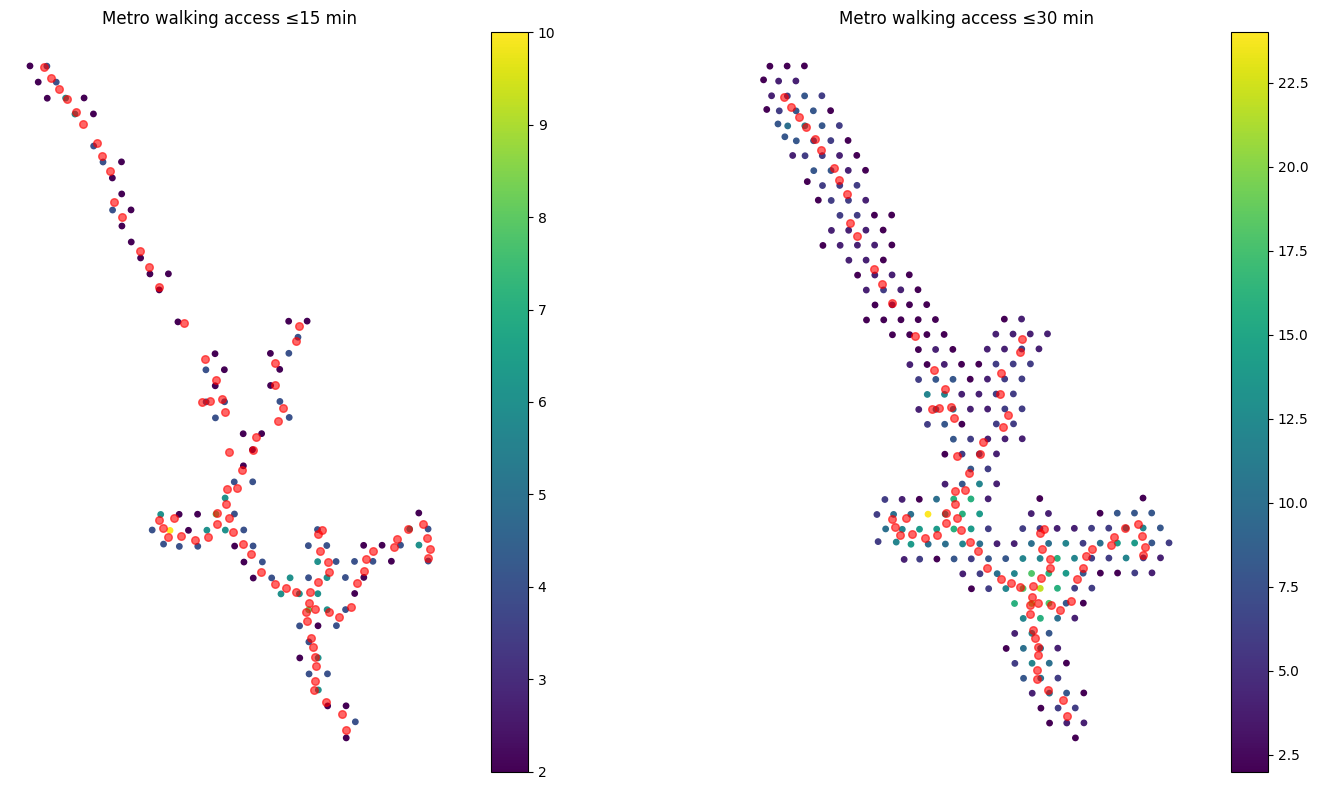

In [30]:
## Plot aggregated points with number of stations
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ≤15 min
points_accessible.plot(
    column="n_metro_15min_walk",
    ax=axes[0],
    cmap="viridis",
    markersize=15,
    legend=True
)

stops_gdf.plot(
    ax=axes[0],
    color="red",
    markersize=30,
    alpha=0.6
)

axes[0].set_title("Metro walking access ≤15 min")
axes[0].axis("off")

# ≤30 min
points_accessible.plot(
    column="n_metro_30min_walk",
    ax=axes[1],
    cmap="viridis",
    markersize=15,
    legend=True
)

stops_gdf.plot(
    ax=axes[1],
    color="red",
    markersize=30,
    alpha=0.6
)

axes[1].set_title("Metro walking access ≤30 min")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [31]:
## WALK accessibility synthesis
df_walk = df[
    (df["duration_min"].notna()) &
    (df["duration_min"] <= 30)
].copy()

# For the WALK mode, the minimum time to the nearest station is used,
# given the deterministic nature of walking and its role as a structural
# access mechanism to the transport network.
df_best = (
    df_walk
    .sort_values(["point_id", "duration_min"])
    .groupby("point_id", as_index=False)
    .first()
)

df_final = (
    df_best
    .merge(n15, on="point_id", how="left")
    .merge(n30, on="point_id", how="left")
)

cols = ["n_metro_15min_walk", "n_metro_30min_walk"]

df_final[cols] = df_final[cols].fillna(0).astype(int)

df_final = df_final.rename(columns={
    "station_id": "best_station_walk",
    "duration_min": "t_walk_min"
})

df_final.head(10)

,point_id,best_station_walk,t_walk_min,distance_m,by_mode,n_metro_15min_walk,n_metro_30min_walk
0,4835,5813,26.13,1524.57,"{'WALK': {'distance_m': 1524.57, 'duration_min...",0,2
1,4890,5813,24.23,1432.89,"{'WALK': {'distance_m': 1432.89, 'duration_min...",0,2
2,4891,5813,8.87,425.05,"{'WALK': {'distance_m': 425.05, 'duration_min'...",2,4
3,4892,5813,27.60,1599.68,"{'WALK': {'distance_m': 1599.68, 'duration_min...",0,4
4,4953,5812,29.03,1688.39,"{'WALK': {'distance_m': 1688.39, 'duration_min...",0,2
5,4954,5813,16.32,954.44,"{'WALK': {'distance_m': 954.44, 'duration_min'...",0,6
6,4955,5813,14.32,895.68,"{'WALK': {'distance_m': 895.68, 'duration_min'...",4,6
7,5019,5792,18.03,1034.92,"{'WALK': {'distance_m': 1034.92, 'duration_min...",0,4
8,5020,5812,3.40,206.85,"{'WALK': {'distance_m': 206.85, 'duration_min'...",2,10
9,5021,5811,10.93,731.71,"{'WALK': {'distance_m': 731.71, 'duration_min'...",2,8


In [32]:
## Export of WALK results
df_geo = df_final.merge(
    points[["point_id", "geometry"]],
    on="point_id",
    how="left"
)

df_geo = gpd.GeoDataFrame(
    df_geo,
    geometry="geometry",
    crs=PROJECT_CRS
)

output_path = "/results/walk_access_metro.geojson"

# Export WALK results in the project canonical CRS (EPSG:4326)
df_geo.to_file(
    output_path,
    driver="GeoJSON"
)